In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import  mean_squared_error, r2_score


In [3]:
# Load dataset
housing = fetch_california_housing()

data = pd.DataFrame(housing.data,columns = housing.feature_names)
data["Price"] = housing.target

In [4]:
# select one feature
x = data[['AveRooms']].values
y = data['Price'].values

In [5]:
# split data
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2,random_state= 42)

In [6]:
# Feature Scaling
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [96]:
w = 0
b = 0
cost_history =[]
learning_rate = 0.02
epochs = 1000

n = len(x_train_scaled)

for i in range(epochs):
    y_pred = w * x_train_scaled.flatten() + b
    dw = (1/n) * np.sum((y_pred - y_train) *x_train_scaled.flatten())
    cost = (1/(2*n)) * np.sum((y_pred - y_train) ** 2)
    cost_history.append(cost)
    db = (1/n) * np.sum(y_pred - y_train)
    w = w - learning_rate * dw
    b = b - learning_rate * db

    if i % 100 == 0:
        cost = (1/(2*n)) * np.sum((y_pred - y_train) ** 2)
        
        print(f"Epoch {i},cost = {cost:4f}")

y_pred_gd = w * x_test_scaled.flatten() + b

Epoch 0,cost = 2.814871
Epoch 100,cost = 0.689648
Epoch 200,cost = 0.652270
Epoch 300,cost = 0.651613
Epoch 400,cost = 0.651601
Epoch 500,cost = 0.651601
Epoch 600,cost = 0.651601
Epoch 700,cost = 0.651601
Epoch 800,cost = 0.651601
Epoch 900,cost = 0.651601


In [97]:
print("Gradient Descent")
print("----------------")
print("Weight :", w)
print("Bais :", b)
print("MSE :", mean_squared_error(y_test, y_pred_gd))
print("R2 Score :", r2_score(y_test,y_pred_gd))

Gradient Descent
----------------
Weight : 0.18323881682652998
Bais : 2.0719469338918577
MSE : 1.2923314439327267
R2 Score : 0.013795337645229111


In [98]:
x_train_ne = np.c_[np.ones((len(x_train),1)),x_train]
x_test_ne = np.c_[np.ones((len(x_test),1)),x_test]

theta = np.linalg.inv(x_train_ne.T @ x_train_ne)@x_train_ne.T @ y_train

y_pred_ne = x_test_ne @ theta

In [99]:
#normal Equation
print("\nNormal Equation")
print("-----------------")
print("Intercept:", theta[0])
print("Slope:", theta[1])
print("MSE:", mean_squared_error(y_test,y_pred_ne))
print("R2 Score:", r2_score(y_test,y_pred_ne))


Normal Equation
-----------------
Intercept: 1.6547622685968417
Slope: 0.07675558963126736
MSE: 1.2923314440807299
R2 Score: 0.013795337532284901


In [100]:
#sort value for smooth regression line

sort_axis = np.argsort(x_test.flatten())
x_sorted = x_test[sort_axis]
y_pred_ne_sorted = y_pred_ne[sort_axis]

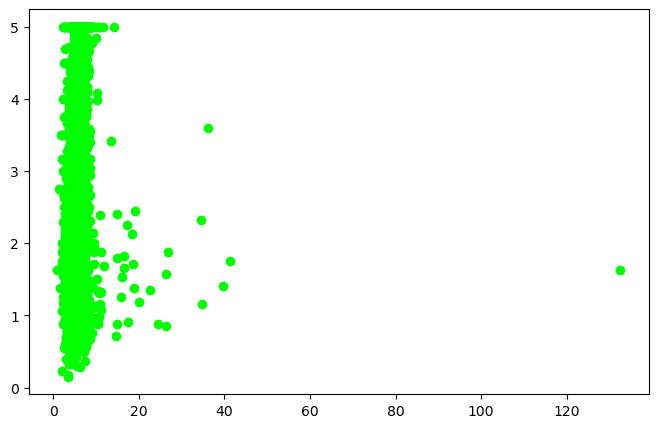

In [101]:
#Regression line visualization

#sort X value for a smooth Line
index = np.argsort(x_test.flatten())
plt.figure(figsize=(8,5))
#scatter plot
plt.scatter(x_test,y_test,color='lime',label='Actual Data')

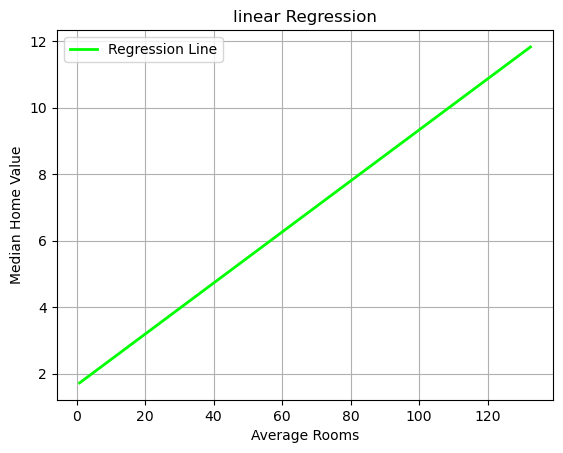

In [102]:
#Regression line
plt.plot(
    x_test.flatten()[index],y_pred_ne[index],color='lime',linewidth=2,label = 'Regression Line'
)
plt.title("linear Regression")
plt.xlabel("Average Rooms")
plt.ylabel("Median Home Value")
plt.legend()
plt.grid(True)
plt.show()

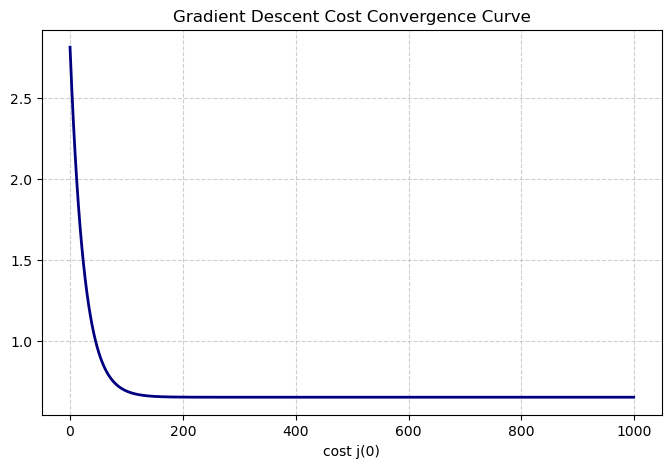

In [103]:
#cost Convergence Curve

plt.figure(figsize=(8,5))

plt.plot(cost_history, color='navy',linewidth=2)
plt.title('Gradient Descent Cost Convergence Curve')
plt.xlabel('Iterations')
plt.xlabel('cost j(0)')
plt.grid(True,linestyle='--',alpha=0.6)

plt.show()